# BAF Variants EDA

Quick validation of the 6 BAF datasets (Base + Variants I–V) before running cross-domain and in-domain experiments.

**Goals:**
1. Confirm shapes, dtypes, column alignment across all 6 datasets
2. Compare fraud rates
3. Verify `x1`, `x2` drop in Variants III & V
4. Show key distributional differences that justify cross-domain experiments

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
ROOT = Path('..').resolve()

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

## 1. Load all 6 BAF datasets (raw CSVs)

In [2]:
datasets = {
    'Base':        pd.read_csv(ROOT / 'datasets' / 'Base.csv'),
    'Variant I':   pd.read_csv(ROOT / 'datasets' / 'Variant I.csv'),
    'Variant II':  pd.read_csv(ROOT / 'datasets' / 'Variant II.csv'),
    'Variant III': pd.read_csv(ROOT / 'datasets' / 'Variant III.csv'),
    'Variant IV':  pd.read_csv(ROOT / 'datasets' / 'Variant IV.csv'),
    'Variant V':   pd.read_csv(ROOT / 'datasets' / 'Variant V.csv'),
}

print('Dataset shapes:')
for name, df in datasets.items():
    fraud_rate = df['fraud_bool'].mean() * 100
    print(f'  {name:15s}  {df.shape[0]:>10,} rows  x  {df.shape[1]:>2} cols  |  fraud = {fraud_rate:.2f}%')

Dataset shapes:
  Base              1,000,000 rows  x  32 cols  |  fraud = 1.10%
  Variant I         1,000,000 rows  x  32 cols  |  fraud = 1.10%
  Variant II        1,000,000 rows  x  32 cols  |  fraud = 1.10%
  Variant III       1,000,000 rows  x  34 cols  |  fraud = 1.10%
  Variant IV        1,000,000 rows  x  32 cols  |  fraud = 1.10%
  Variant V         1,000,000 rows  x  34 cols  |  fraud = 1.10%


## 2. Column alignment check

In [3]:
base_cols = set(datasets['Base'].columns)

for name, df in datasets.items():
    cols = set(df.columns)
    extra = cols - base_cols
    missing = base_cols - cols
    if extra or missing:
        print(f'{name}: extra={extra}, missing={missing}')
    else:
        print(f'{name}: columns match Base exactly')

Base: columns match Base exactly
Variant I: columns match Base exactly
Variant II: columns match Base exactly
Variant III: extra={'x2', 'x1'}, missing=set()
Variant IV: columns match Base exactly
Variant V: extra={'x2', 'x1'}, missing=set()


## 3. Verify x1, x2 drop via data.py loaders

In [4]:
from data import load_dataset

# Load Base and Variant III through our registered loaders
X_base, _, _, _ = load_dataset('baf_base')
X_var3, _, _, _ = load_dataset('baf_var3')
X_var5, _, _, _ = load_dataset('baf_var5')

print(f'Base columns ({len(X_base.columns)}):    {sorted(X_base.columns)[:5]} ...')
print(f'Var III columns ({len(X_var3.columns)}): {sorted(X_var3.columns)[:5]} ...')
print(f'Var V columns ({len(X_var5.columns)}):   {sorted(X_var5.columns)[:5]} ...')
print()
print(f'Columns match: Base vs Var III = {list(X_base.columns) == list(X_var3.columns)}')
print(f'Columns match: Base vs Var V  = {list(X_base.columns) == list(X_var5.columns)}')
assert list(X_base.columns) == list(X_var3.columns), 'Column mismatch after x1/x2 drop!'
assert list(X_base.columns) == list(X_var5.columns), 'Column mismatch after x1/x2 drop!'
print('\nAll column alignments verified.')

Base columns (30):    ['bank_branch_count_8w', 'bank_months_count', 'credit_risk_score', 'current_address_months_count', 'customer_age'] ...
Var III columns (30): ['bank_branch_count_8w', 'bank_months_count', 'credit_risk_score', 'current_address_months_count', 'customer_age'] ...
Var V columns (30):   ['bank_branch_count_8w', 'bank_months_count', 'credit_risk_score', 'current_address_months_count', 'customer_age'] ...

Columns match: Base vs Var III = True
Columns match: Base vs Var V  = True

All column alignments verified.


## 4. Fraud rate comparison

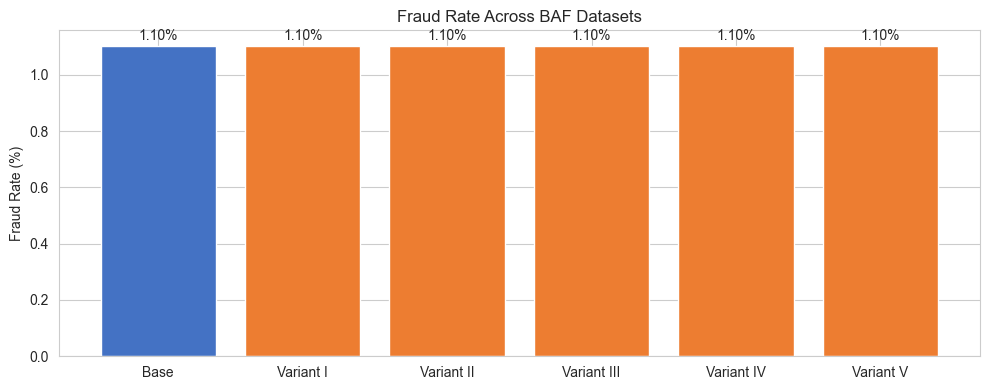

In [5]:
fraud_rates = {name: df['fraud_bool'].mean() * 100 for name, df in datasets.items()}

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#4472C4'] + ['#ED7D31'] * 5
bars = ax.bar(fraud_rates.keys(), fraud_rates.values(), color=colors, edgecolor='white')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Fraud Rate Across BAF Datasets')
for bar, rate in zip(bars, fraud_rates.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{rate:.2f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 5. Key feature distributions (Base vs Variants)

Compare distributions of a few numerical features to visualise the covariate shift.

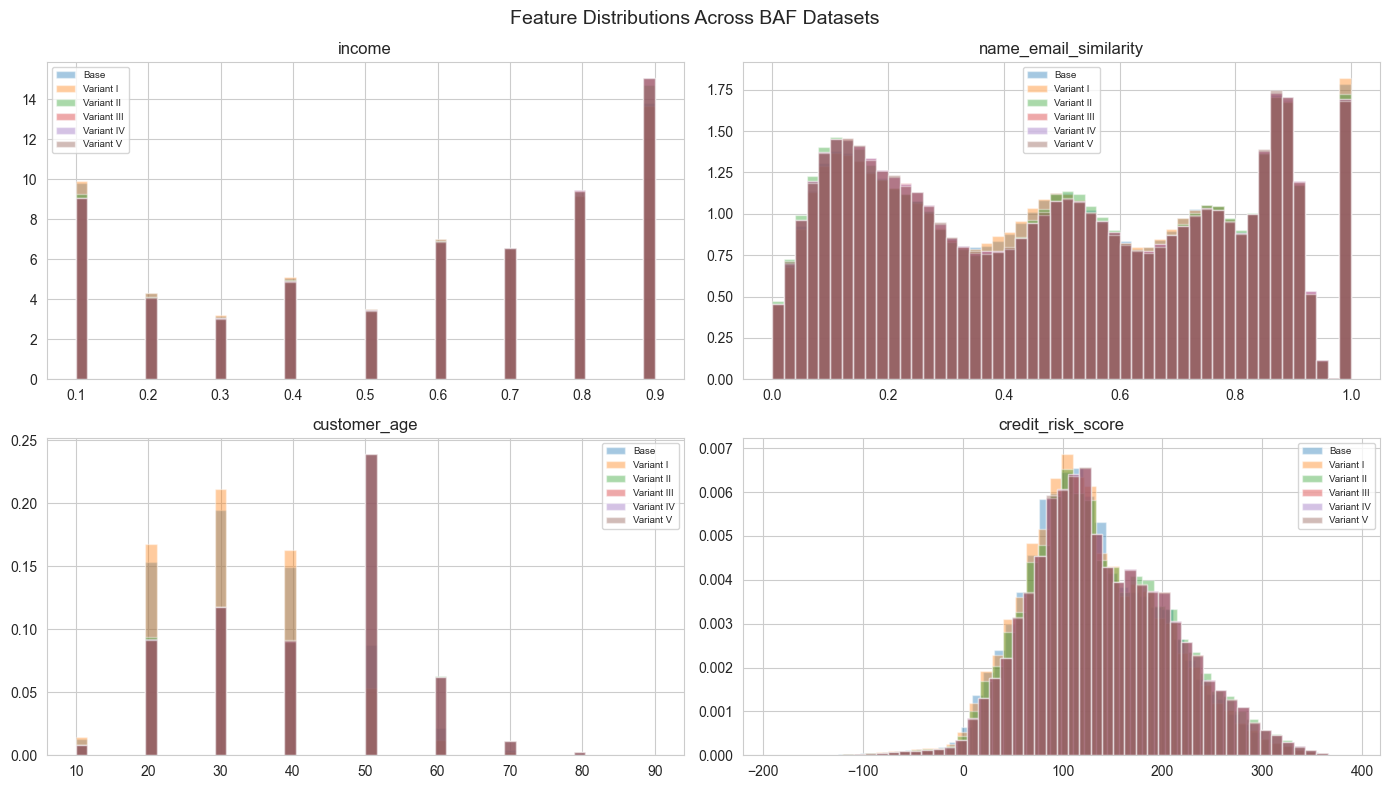

In [6]:
# Select a few numerical features present in all datasets
num_features = ['income', 'name_email_similarity', 'customer_age', 'credit_risk_score']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, feat in zip(axes.flat, num_features):
    for name, df in datasets.items():
        if feat in df.columns:
            ax.hist(df[feat].dropna(), bins=50, alpha=0.4, label=name, density=True)
    ax.set_title(feat)
    ax.legend(fontsize=7)
plt.suptitle('Feature Distributions Across BAF Datasets', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Categorical feature distribution comparison

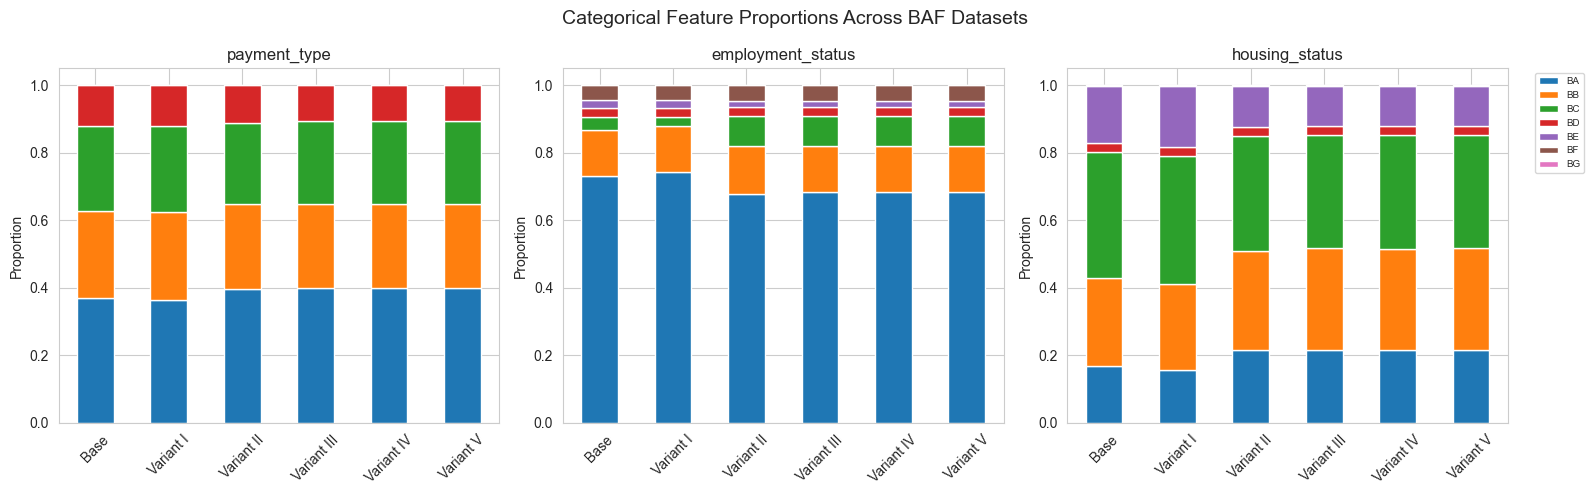

: 

In [ ]:
cat_features = ['payment_type', 'employment_status', 'housing_status']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, cat_features):
    props = pd.DataFrame({
        name: df[feat].value_counts(normalize=True)
        for name, df in datasets.items()
        if feat in df.columns
    }).T
    props.plot(kind='bar', stacked=True, ax=ax, legend=False)
    ax.set_title(feat)
    ax.set_ylabel('Proportion')
    ax.tick_params(axis='x', rotation=45)
axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.suptitle('Categorical Feature Proportions Across BAF Datasets', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Summary

All 6 BAF datasets loaded successfully. Key findings:
- Base + Variants I, II, IV have 32 columns (after dropping `month`)
- Variants III & V have 34 columns (extra `x1`, `x2`); our loaders correctly drop them to 32
- Fraud rates vary across variants (especially Variant II with label shift)
- Feature distributions differ visibly → justifies cross-domain robustness analysis